<a href="https://colab.research.google.com/github/ParamAhuja/DL_Notebooks/blob/main/Xavier_and_He.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [30]:
df = pd.read_csv('https://raw.githubusercontent.com/ParamAhuja/DL_Notebooks/refs/heads/main/datasets/ushape.csv')

In [31]:
df.columns = ["X", "Y", "class"]

In [32]:
df.head()

,X,Y,class
0,2.115098,-0.046244,1.0
1,0.882490,-0.075756,0.0
2,-0.055144,-0.037332,1.0
3,0.829545,-0.539321,1.0
4,2.112857,0.662084,1.0


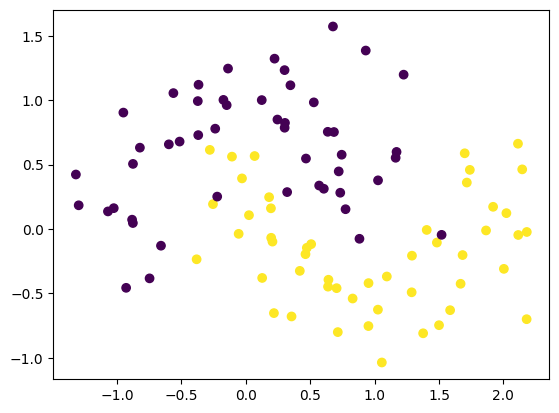

In [33]:
plt.scatter(df['X'],df['Y'],c=df['class'])

In [34]:
X = df.iloc[:,0:2].values
y = df.iloc[:,-1].values

In [35]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [36]:
model = Sequential()

model.add(Dense(10,activation='tanh',input_dim=2,kernel_initializer='glorot_normal')) # and he_normal
model.add(Dense(10,activation='tanh',kernel_initializer='glorot_normal'))
model.add(Dense(10,activation='tanh',kernel_initializer='glorot_normal'))
model.add(Dense(10,activation='tanh',kernel_initializer='glorot_normal'))
model.add(Dense(1,activation='sigmoid'))

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
model.get_weights()

[array([[-0.16443323,  0.07640985, -0.57207245, -0.32194138,  0.62897116,
         -0.08047811, -0.6273817 ,  0.22567305,  0.76833594,  0.24886422],
        [-0.7692356 ,  0.06863351, -0.63618517,  0.04125628, -0.8092095 ,
         -0.5312793 ,  0.06899777, -0.37061244, -0.10411119,  0.47033364]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.00684676,  0.12651692,  0.41464418,  0.1646604 , -0.5461679 ,
         -0.31798238,  0.6567636 , -0.2257028 ,  0.11453546, -0.20983472],
        [-0.47755295, -0.02570944,  0.7075651 , -0.326581  ,  0.2019879 ,
         -0.08634368, -0.30992743,  0.16224349,  0.16909134,  0.23526062],
        [ 0.27599475,  0.1248474 ,  0.00849862, -0.43347764,  0.24881276,
         -0.22665565, -0.5046766 , -0.26851732,  0.50827837, -0.4105625 ],
        [-0.35813287, -0.08766327, -0.39903808,  0.38627392,  0.1385321 ,
          0.10306041,  0.22557248, -0.3635968 , -0.4191859 , -0.03046563],
        [-0.12189

In [38]:
initial_weights = model.get_weights()

In [39]:
initial_weights[0] = np.random.randn(2,10)*np.sqrt(1/2)
initial_weights[1] = np.zeros(model.get_weights()[1].shape)
initial_weights[2] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[3] = np.zeros(model.get_weights()[3].shape)
initial_weights[4] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[5] = np.zeros(model.get_weights()[5].shape)
initial_weights[6] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[7] = np.zeros(model.get_weights()[7].shape)
initial_weights[8] = np.random.randn(10,1)*np.sqrt(1/10)
initial_weights[9] = np.zeros(model.get_weights()[9].shape)

In [40]:
model.set_weights(initial_weights)

In [41]:
model.get_weights()

[array([[-0.8551319 , -0.40289363,  1.3280691 ,  0.6194419 , -0.13848908,
          0.43708822,  0.2227826 , -0.59277904,  0.81682587,  0.00292313],
        [-0.7233685 , -0.73266035,  0.16975658,  0.17037028,  0.06623572,
         -0.4366596 ,  0.67992246,  0.57481337,  0.38956392,  0.15681532]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[-0.13392673, -0.13714449,  0.16545652, -0.28224677,  0.43989146,
          0.48056722, -0.04668721, -0.09598809, -0.02201216,  0.4826822 ],
        [-0.1178251 ,  0.36093232,  0.14856993, -0.26250386, -0.01784386,
          0.45903713,  0.1193663 ,  0.18969172, -0.12220304, -0.29192537],
        [ 0.213065  , -0.05187109, -0.16019544, -0.0114667 , -0.44842345,
         -0.05780212, -0.3373547 , -0.01577784,  0.2608045 , -0.1578    ],
        [-0.2654657 , -0.56433886, -0.02237342, -0.07622605,  0.24396256,
         -0.2018639 ,  0.00130043,  0.34055698,  0.18637395, -0.10744832],
        [-0.29293

In [42]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [43]:
history = model.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 156ms/step - accuracy: 0.4393 - loss: 0.7498 - val_accuracy: 0.6500 - val_loss: 0.6899
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.4286 - loss: 0.7379 - val_accuracy: 0.7000 - val_loss: 0.6711
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.4671 - loss: 0.7334 - val_accuracy: 0.7000 - val_loss: 0.6545
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.4914 - loss: 0.7091 - val_accuracy: 0.7000 - val_loss: 0.6391
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.5285 - loss: 0.7073 - val_accuracy: 0.7000 - val_loss: 0.6251
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.5543 - loss: 0.6906 - val_accuracy: 0.7500 - val_loss: 0.6119
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5700 - loss: 0.6713 - val_accuracy: 0.7000 - val_loss: 0.5991
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.6007 - loss: 0.6641 - val_accuracy: 0.7000 - val_loss

In [44]:
model.get_weights()

[array([[-0.9393231 , -0.40972826,  1.4120946 ,  0.60495514, -0.20036526,
          0.42231736,  0.28058425, -0.51029223,  0.8939564 , -0.07783133],
        [-0.7596829 , -0.70242435,  0.17271525,  0.10150341,  0.16208747,
         -0.53771335,  0.60376745,  0.5657141 ,  0.46228233,  0.24517657]],
       dtype=float32),
 array([-0.21443075,  0.02190544, -0.20657054,  0.04900783,  0.03269956,
        -0.04142731,  0.04468875,  0.01550641, -0.18598953,  0.01821645],
       dtype=float32),
 array([[-0.16824162, -0.21710691,  0.12355729, -0.2437029 ,  0.39208815,
          0.42662638,  0.00235324, -0.08031022,  0.05835718,  0.5260984 ],
        [-0.18578027,  0.29055604,  0.18588075, -0.19499297, -0.0940654 ,
          0.3598918 ,  0.20009834,  0.24942942, -0.03202989, -0.21690622],
        [ 0.23912391, -0.08639917, -0.12488451, -0.04933775, -0.40140715,
          0.01538227, -0.38318214, -0.02509664,  0.19620728, -0.18899657],
        [-0.29060078, -0.53616786,  0.08482873, -0.06149125, 

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step


<Axes: >

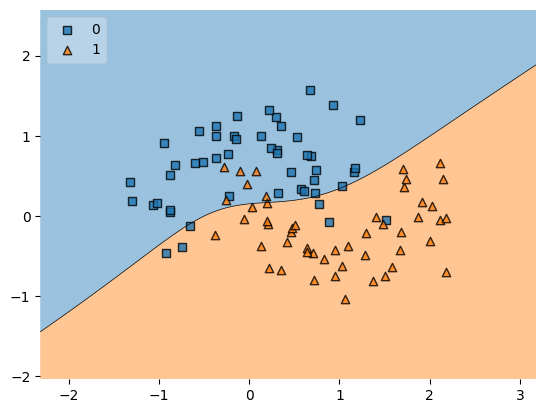

In [45]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype('int'), clf=model, legend=2)

In [46]:
(np.random.randn(10,10)*0.01).min()

np.float64(-0.02304935284862045)

In [47]:
(np.random.randn(10,10)*0.01).max()

np.float64(0.022172617209768503)